In [1]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
# import healpy as hp

from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/Users/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
def print_summary(mask):
    print('target density: {:.1f} per sq deg'.format(np.sum(mask)/area_clean*downsample_factor))

In [4]:
downsample_factor = 16
field = 'south'

In [5]:
cat_columns = ['TYPE', 'RA', 'DEC', 'EBV', 
          'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 
          'NOBS_G', 'NOBS_R', 'NOBS_Z', 'NOBS_W1', 'NOBS_W2', 
          'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 
          'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 
          'MASKBITS',
          'z_phot_mean', 'z_phot_median', 'z_phot_std', 'z_phot_l68', 'z_phot_u68', 'z_phot_l95', 'z_phot_u95',
          'z_spec', 'survey', 'training']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_lrg_selection/dr9m-sep26-2020/lrg_extended_20201016_ds_{}.fits'.format(field), columns=cat_columns))
print(len(cat))
if field=='south':
    mask = cat['DEC']<32.375
elif field=='north':
    mask = (cat['DEC']>32.375) & (cat['RA']>70) & (cat['RA']<310)
else:
    raise ValueError('invalid field')
mask &= (cat['NOBS_G']>=2) & (cat['NOBS_R']>=2) & (cat['NOBS_Z']>=2)
mask &= cat['DEC']>-30
cat = cat[mask]
print(len(cat))

randoms_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS']
randoms_full_size = 63283970
randoms_load_size = int(1e7)
randoms_density = 5000./randoms_full_size*randoms_load_size
randoms = fitsio.read('/Users/rongpu/Documents/Data/desi_lrg_selection/dr9m-sep26-2020/randoms-1-0.fits', 
                      columns=randoms_columns, rows=np.arange(randoms_load_size))
print(len(randoms))
if field=='south':
    mask = randoms['DEC']<32.375
elif field=='north':
    mask = (randoms['DEC']>32.375) & (randoms['RA']>70) & (randoms['RA']<310)
else:
    raise ValueError('invalid field')
mask &= (randoms['NOBS_G']>=2) & (randoms['NOBS_R']>=2) & (randoms['NOBS_Z']>=2)
mask &= randoms['DEC']>-30
randoms = randoms[mask]
print(len(randoms))

8807989
8535911
10000000
5026626


__Clean up the data__

In [6]:
maskbits = [1, 5, 6, 7, 8, 9, 11, 12, 13]

mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('{:} ({:.1f}%) objects removed by maskbits'.format(np.sum(~mask_clean), np.sum(~mask_clean)/len(mask_clean)*100))
cat = cat[mask_clean]
print(len(cat))

mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:} ({:.1f}%) randoms removed by maskbits'.format(np.sum(~mask_clean), np.sum(~mask_clean)/len(mask_clean)*100))
randoms = randoms[mask_clean]
print(len(randoms))

502007 (5.9%) objects removed by maskbits
8033904
276147 (5.5%) randoms removed by maskbits
4750479


__Basic quality cuts__

In [7]:
mask = (cat['FLUX_R']>0) & (cat['FLUX_IVAR_R']>0)
mask &= (cat['FLUX_Z']>0) & (cat['FLUX_IVAR_Z']>0)
mask &= (cat['FLUX_W1']>0) & (cat['FLUX_IVAR_W1']>0)
print(np.sum(~mask)/len(mask), np.sum(~mask))
cat = cat[mask]
print(len(cat))

0.00018384586124006462 1477
8032427


__Remove objects with invalid photo-z's__

In [8]:
mask = cat['z_phot_median']==-99
print(np.sum(mask))
cat = cat[~mask]

67


In [9]:
area_clean = len(randoms)/randoms_density
print('Arae = {:.2f} sq. deg.'.format(area_clean))

Arae = 6012.58 sq. deg.


In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    rfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    rfibermag[~np.isfinite(rfibermag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.
    
    gflux_ivar = cat['FLUX_IVAR_R']
    
    cat['z_phot'] = cat['z_phot_median']

In [11]:
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag, rfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag', 'rfibermag'])

In [12]:
z_phot = cat['z_phot_median']
# Perturb the photo-z's by the estimated errors
cat['z_phot_1_sigma'] = (cat['z_phot_u68']-cat['z_phot_l68'])/2
np.random.seed(123)
z_phot_perturb = cat['z_phot_median'] + np.random.randn(len(cat)) * cat['z_phot_1_sigma']

In [13]:
# Load stars from a sweep catalog
cat_psf = fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/catalogs/dr8.0/temp/sweep-120p010-130p015.fits',
                  columns=['TYPE','NOBS_G', 'NOBS_R', 'NOBS_Z', 'FLUX_Z', 'FIBERFLUX_Z', 'FLUX_IVAR_Z', 'MW_TRANSMISSION_Z'])
print(len(cat_psf))
cat_psf = Table(cat_psf)
cat_psf['FLUX_Z_EC'] = cat_psf['FLUX_Z']/cat_psf['MW_TRANSMISSION_Z']
cat_psf['FIBERFLUX_Z_EC'] = cat_psf['FIBERFLUX_Z']/cat_psf['MW_TRANSMISSION_Z']
mask = cat_psf['TYPE']=='PSF '
mask &= (cat_psf['NOBS_G']>=2) & (cat_psf['NOBS_R']>=2) & (cat_psf['NOBS_Z']>=2)
mask &= (cat_psf['FLUX_Z_EC']>0) & (cat_psf['FLUX_IVAR_Z']>0)
mask &= (cat_psf['FLUX_Z_EC'] > 10**(0.4*(22.5-20.5))) # zmag<20.5
idx = np.where(mask)[0]
print(len(idx))

cat_psf = fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/catalogs/dr8.0/temp/sweep-120p010-130p015.fits',
                  rows=idx)
cat_psf = Table(cat_psf)
cat_psf['TYPE'] = cat_psf['TYPE'].astype(str)

# Apply extinction correction
cat_psf['FLUX_G_EC'] = cat_psf['FLUX_G']/cat_psf['MW_TRANSMISSION_G']
cat_psf['FLUX_R_EC'] = cat_psf['FLUX_R']/cat_psf['MW_TRANSMISSION_R']
cat_psf['FLUX_Z_EC'] = cat_psf['FLUX_Z']/cat_psf['MW_TRANSMISSION_Z']
cat_psf['FLUX_W1_EC'] = cat_psf['FLUX_W1']/cat_psf['MW_TRANSMISSION_W1']
cat_psf['FLUX_W2_EC'] = cat_psf['FLUX_W2']/cat_psf['MW_TRANSMISSION_W2']
cat_psf['FIBERFLUX_G_EC'] = cat_psf['FIBERFLUX_G']/cat_psf['MW_TRANSMISSION_G']
cat_psf['FIBERFLUX_R_EC'] = cat_psf['FIBERFLUX_R']/cat_psf['MW_TRANSMISSION_R']
cat_psf['FIBERFLUX_Z_EC'] = cat_psf['FIBERFLUX_Z']/cat_psf['MW_TRANSMISSION_Z']
cat_psf['FIBERTOTFLUX_G_EC'] = cat_psf['FIBERTOTFLUX_G']/cat_psf['MW_TRANSMISSION_G']
cat_psf['FIBERTOTFLUX_R_EC'] = cat_psf['FIBERTOTFLUX_R']/cat_psf['MW_TRANSMISSION_R']
cat_psf['FIBERTOTFLUX_Z_EC'] = cat_psf['FIBERTOTFLUX_Z']/cat_psf['MW_TRANSMISSION_Z']

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_G_EC'])
    rmag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_R_EC'])
    zmag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_Z_EC'])
    w1mag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_W1_EC'])
    w2mag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_W2_EC'])
    zfibermag_psf = 22.5 - 2.5*np.log10(cat_psf['FIBERFLUX_Z_EC'])
    rfibermag_psf = 22.5 - 2.5*np.log10(cat_psf['FIBERFLUX_R_EC'])

    gmag_psf[~np.isfinite(gmag_psf)] = 100.
    rmag_psf[~np.isfinite(rmag_psf)] = 100.
    zmag_psf[~np.isfinite(zmag_psf)] = 100.
    w1mag_psf[~np.isfinite(w1mag_psf)] = 100.
    w2mag_psf[~np.isfinite(w2mag_psf)] = 100.
    rfibermag_psf[~np.isfinite(rfibermag_psf)] = 100.
    zfibermag_psf[~np.isfinite(zfibermag_psf)] = 100.

4044945
466455


-------
# Optical selection

In [47]:
desi_params = {
    'zfiber_max':21.5,
    'ns_a':0.8, 'ns_b':-0.6,
    'opt_rz_slope1':0.45, 'opt_rz_slope2':0.19,
    'opt_rz_inter1':-16.83,  'opt_rz_inter2':-13.80, 
}

desi2_params = {
    'zfiber_max':22,
    'ns_a':0.8, 'ns_b':-0.6,
    'opt_rz_slope':0.3, 'opt_rz_inter':-16.60, 
}

In [48]:
mask = ((zfibermag<22.0) | (zmag<21.0)) & (cat['TYPE']!='PSF')
print('non-PSF:', np.sum(mask))
mask = ((zfibermag<22.0) | (zmag<21.0)) & (cat['TYPE']=='PSF')
print('PSF:    ', np.sum(mask))

non-PSF: 3971236
PSF:     413309


In [49]:
# All galaxies
np.random.seed(342)
idx_psf = np.random.choice(len(cat_psf), size=15000, replace=False)
mask = (zfibermag<22.0) & (cat['TYPE']!='PSF')
idx_all = np.random.choice(np.where(mask)[0], size=40000, replace=False)

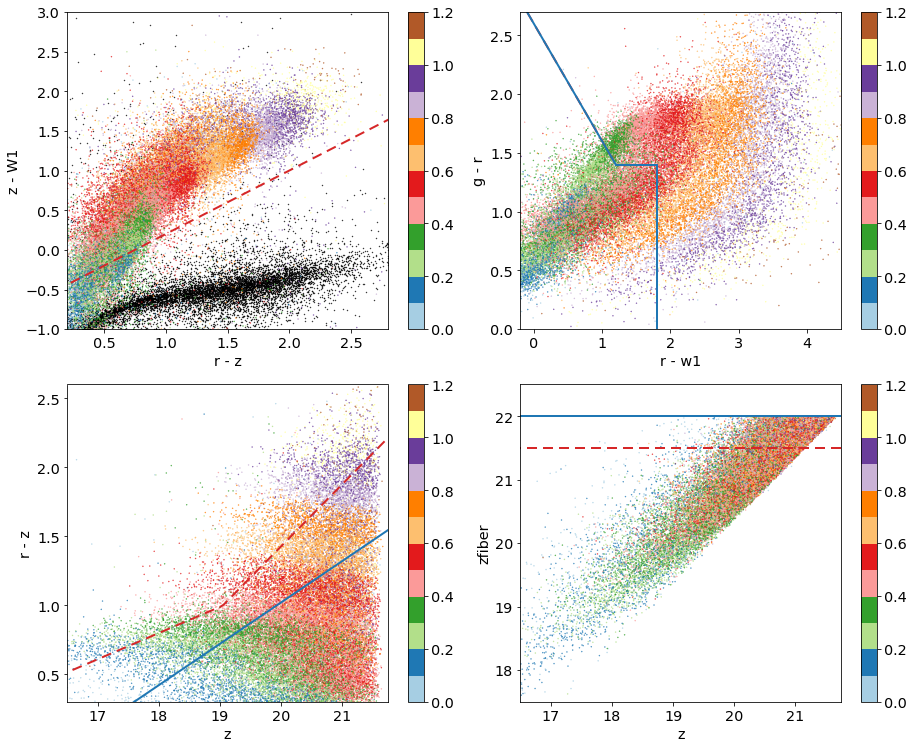

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10.5))

################# non-stellar cut #################
axes[0, 0].scatter((rmag_psf-zmag_psf)[idx_psf], (zmag_psf-w1mag_psf)[idx_psf], 
            c='k', s=0.15, vmin=0., vmax=1.2)
im = axes[0, 0].scatter((rmag-zmag)[idx_all], (zmag-w1mag)[idx_all], 
            c=z_phot[idx_all], s=0.15, cmap='Paired', vmin=0., vmax=1.2)
axes[0, 0].set_xlabel('r - z')
axes[0, 0].set_ylabel('z - W1')
axes[0, 0].axis([0.2, 2.8, -1, 3])
fig.colorbar(im, ax=axes[0, 0])

# Lines -- DESI
x = np.linspace(0, 3)
y = desi_params['ns_a'] * x + desi_params['ns_b']
axes[0, 0].plot(x, y, 'C3', lw=2, ls='--', dashes=(5, 3))
# Lines -- DESI II
x = np.linspace(0, 3)
y = desi2_params['ns_a'] * x + desi2_params['ns_b']
axes[1, 0].plot(x, y, 'C0',  lw=2)

################# g-r vs r-W1 #################
im = axes[0, 1].scatter((rmag-w1mag)[idx_all], (gmag-rmag)[idx_all], 
         c=z_phot[idx_all], s=0.15, cmap='Paired', vmin=0., vmax=1.2)
axes[0, 1].set_xlabel('r - w1')
axes[0, 1].set_ylabel('g - r')
axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
fig.colorbar(im, ax=axes[0, 1])

# Lines -- DESI
x1 = np.linspace(-5, 1.2)
y1 = 2.6 - x1
x2 = np.linspace(1.2, 1.8)
y2 = 1.4 * np.ones_like(x1)
y3 = np.linspace(-5, 1.4)
x3 = 1.8 * np.ones_like(y3)
axes[0, 1].plot(x1, y1, 'C3', lw=2, ls='--', dashes=(5, 3))
axes[0, 1].plot(x2, y2, 'C3', lw=2, ls='--', dashes=(5, 3))
axes[0, 1].plot(x3, y3, 'C3', lw=2, ls='--', dashes=(5, 3))

# Lines -- DESI II
x1 = np.linspace(-5, 1.2)
y1 = 2.6 - x1
x2 = np.linspace(1.2, 1.8)
y2 = 1.4 * np.ones_like(x1)
y3 = np.linspace(-5, 1.4)
x3 = 1.8 * np.ones_like(y3)
axes[0, 1].plot(x1, y1, 'C0', lw=2)
axes[0, 1].plot(x2, y2, 'C0', lw=2)
axes[0, 1].plot(x3, y3, 'C0', lw=2)

################# optical sliding cut #################
im = axes[1, 0].scatter((zmag)[idx_all], (rmag-zmag)[idx_all], 
         c=z_phot[idx_all], s=0.15, cmap='Paired', vmin=0., vmax=1.2)
axes[1, 0].set_xlabel('z')
axes[1, 0].set_ylabel('r - z')
axes[1, 0].axis([16.5, 21.75, 0.3, 2.6])
fig.colorbar(im, ax=axes[1, 0])

# Lines -- DESI
x = np.linspace(15, 23, 200)
y = np.zeros(len(x))
mask = (x<19.04)
y[mask] = (x[mask] + desi_params['opt_rz_inter2']) * desi_params['opt_rz_slope2']
mask = (x>=19.04)
y[mask] = (x[mask] + desi_params['opt_rz_inter1']) * desi_params['opt_rz_slope1']
axes[1, 0].plot(x, y, 'C3', lw=2, ls='--', dashes=(5, 3))

# Lines -- DESI II
x = np.linspace(15, 23, 200)
y = np.zeros(len(x))
y = (x + desi2_params['opt_rz_inter']) * desi2_params['opt_rz_slope']
axes[1, 0].plot(x, y, 'C0', lw=2)

################# zfiber vs z #################
im = axes[1, 1].scatter((zmag)[idx_all], (zfibermag)[idx_all], 
         c=z_phot[idx_all], s=0.15, cmap='Paired', vmin=0., vmax=1.2)
axes[1, 1].set_xlabel('z')
axes[1, 1].set_ylabel('zfiber')
axes[1, 1].axis([16.5, 21.75, 17.5, 22.5])
fig.colorbar(im, ax=axes[1, 1])

# Lines -- DESI
x = np.linspace(0, 100)
y = desi_params['zfiber_max'] * np.ones_like(x)
axes[1, 1].plot(x, y, 'C3', lw=2, ls='--', dashes=(5, 3))
# Lines -- DESI II
x = np.linspace(0, 100)
y = desi2_params['zfiber_max'] * np.ones_like(x)
axes[1, 1].plot(x, y, 'C0', lw=2)

plt.tight_layout()
plt.savefig('plots/desi_2_lrg.png', dpi=110)
plt.show()